<a href="https://colab.research.google.com/github/adombe/AVCA_2026/blob/main/AVCAD_ANDREA_DOMBE_DEEPSEEK_PERPLEXITY_EX7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EXERCISE 1:
Prompt 1.1: From the simple_results table, identify which environmental variables have a statistically significant relationship with species richness (p < 0.05). List these variables in order from highest to lowest R² value.

Prompt 1.2: For the variable with the highest R², write an interpretation of the slope coefficient. State whether the relationship is positive or negative and explain what this means for species richness.

Prompt 1.3: Examine the 7 scatter plots. Describe which variable shows the strongest linear relationship with species richness and which variable shows the weakest.

Prompt 1.4: Report the F-statistic and p-value for the model using temp_ann as the predictor. State what these values indicate about the model's overall significance.

Prompt 1.5: Based on the R² values, state what proportion of variance in species richness is explained by Altitude and what proportion is explained by temp_ann.

Dataset shape: (4819, 8)
Rows used for analysis: 4819 out of 5011 total

EXERCISE 1: Simple Linear Regressions
              predictor   slope  intercept  r_squared  f_statistic  p_value
0              Altitude -0.0024     4.0426     0.1056     568.5996      0.0
1    Actual_river_slope -0.0253     3.3652     0.0506     256.8556      0.0
2  Elevation_mean_catch -0.0015     4.1514     0.0627     322.0412      0.0
3        prec_ann_catch -0.0013     4.2482     0.0234     115.2222      0.0
4              temp_ann  0.3906    -2.1806     0.1116     604.9296      0.0
5              temp_jan  0.2157     1.6587     0.0512     260.1143      0.0
6              temp_jul  0.3232    -3.6582     0.1077     581.3954      0.0




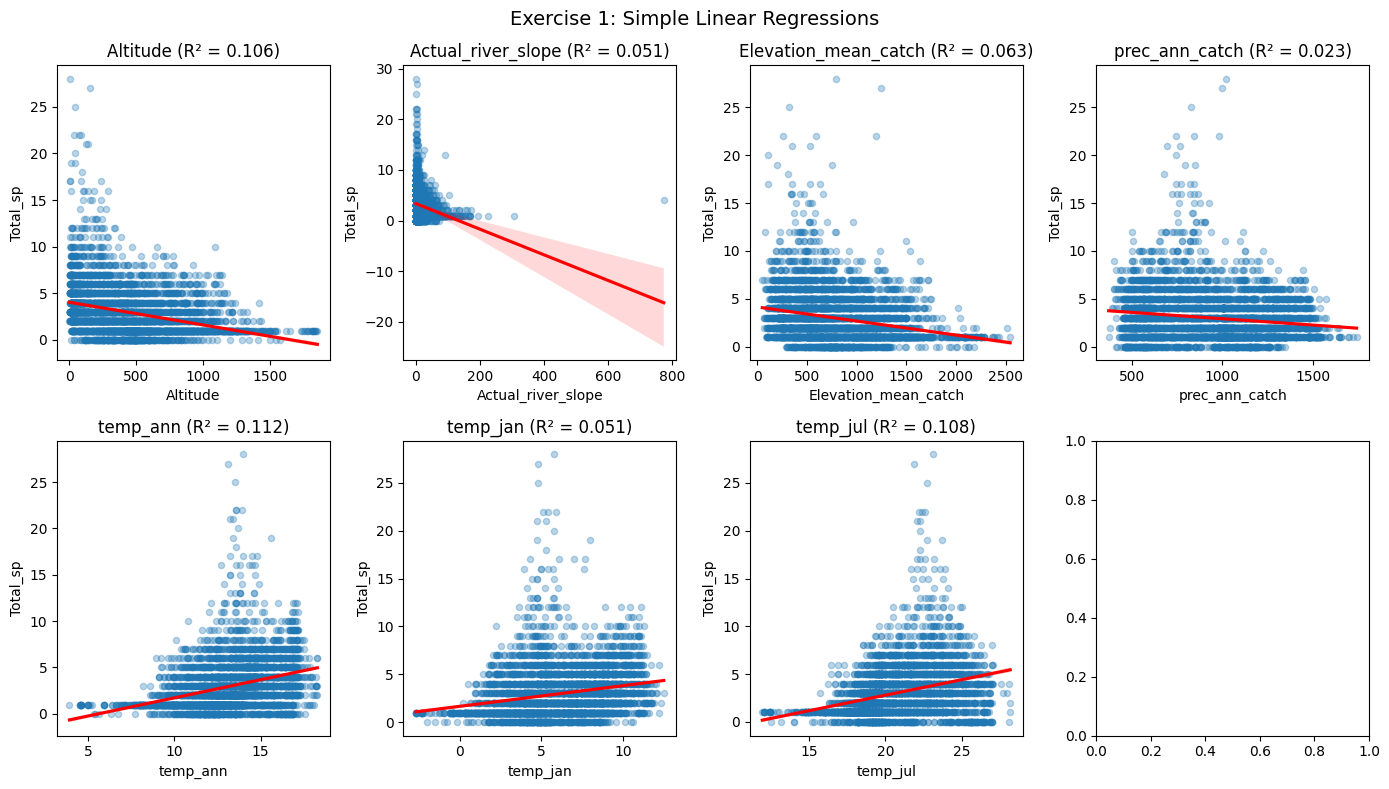

In [14]:
# ============================================
# EXERCISE 1: Simple Linear Regression
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv('/content/EFIplus_medit.csv', sep=';')

# Define variables
response = 'Total_sp'
predictors = [
    'Altitude',
    'Actual_river_slope',
    'Elevation_mean_catch',
    'prec_ann_catch',
    'temp_ann',
    'temp_jan',
    'temp_jul'
]

# Clean data - remove rows with missing values
data = df[[response] + predictors].dropna().copy()
print(f"Dataset shape: {data.shape}")
print(f"Rows used for analysis: {len(data)} out of {len(df)} total\n")

# Run simple linear regressions
print("="*60)
print("EXERCISE 1: Simple Linear Regressions")
print("="*60)

results = []
for x in predictors:
    model = smf.ols(f'{response} ~ {x}', data=data).fit()
    results.append({
        'predictor': x,
        'slope': model.params[x],
        'intercept': model.params['Intercept'],
        'r_squared': model.rsquared,
        'f_statistic': model.fvalue,
        'p_value': model.f_pvalue
    })

# Create results table
simple_results = pd.DataFrame(results)
print(simple_results.round(4))
print("\n")

# Plot simple regressions
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()
for i, x in enumerate(predictors):
    sns.regplot(data=data, x=x, y=response, ax=axes[i],
                scatter_kws={'alpha':0.3, 's':20}, line_kws={'color':'red'})
    axes[i].set_title(f'{x} (R² = {simple_results.loc[i, "r_squared"]:.3f})')
plt.suptitle('Exercise 1: Simple Linear Regressions', fontsize=14)
plt.tight_layout()
plt.show()

EXERCISE 2:
Prompt 2.1: From the multiple regression summary table, identify which variables are statistically significant (p < 0.05) when all predictors are included together. Compare this to Exercise 1 and state which variable(s) lost significance.

Prompt 2.2: Examine the compare table showing simple vs multiple slopes. Identify which variable had the largest change in coefficient and provide a possible explanation for why this change occurred.

Prompt 2.3: Compare the R² from the simple regression of temp_ann (Exercise 1) with the R² from the multiple regression. State how much additional variance is explained by adding all other predictors.

Prompt 2.4: Examine the partial dependence plot for temp_ann. Describe how the predicted species richness changes as temperature increases while holding all other variables constant.

Prompt 2.5: Compare the partial dependence plot for Altitude with its simple regression scatter plot from Exercise 1. Describe the differences and explain why the relationship might appear different when holding other variables constant.

                            OLS Regression Results                            
Dep. Variable:               Total_sp   R-squared:                       0.195
Model:                            OLS   Adj. R-squared:                  0.194
Method:                 Least Squares   F-statistic:                     166.8
Date:                Thu, 14 May 2026   Prob (F-statistic):          1.64e-221
Time:                        15:24:42   Log-Likelihood:                -10802.
No. Observations:                4819   AIC:                         2.162e+04
Df Residuals:                    4811   BIC:                         2.167e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.3658 

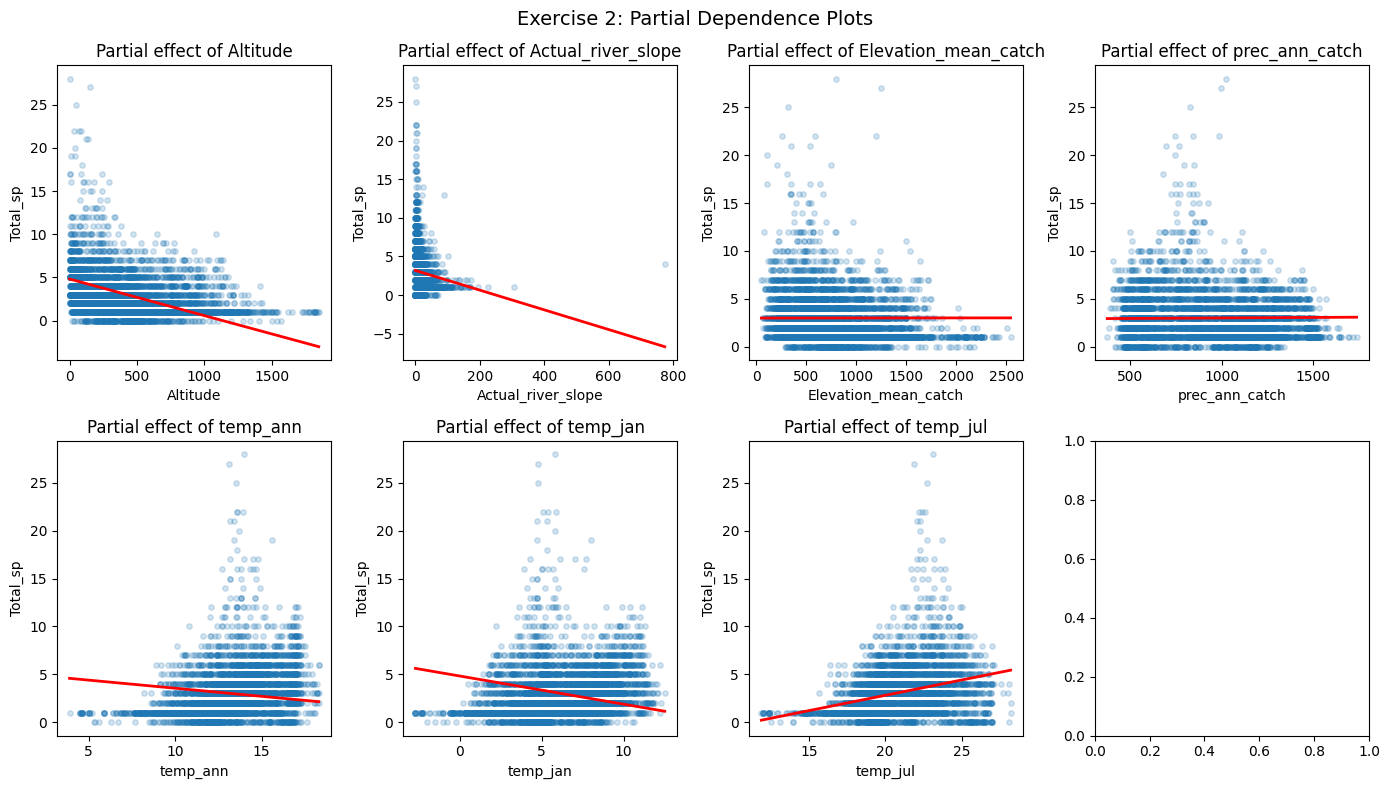

Variables significant in multiple regression (p < 0.05): ['Altitude', 'Actual_river_slope', 'temp_jan', 'temp_jul']


In [15]:
# ============================================
# EXERCISE 2: Multiple Linear Regression
# ============================================

# Build formula with all predictors
formula = f'{response} ~ ' + ' + '.join(predictors)
multi_model = smf.ols(formula, data=data).fit()
print(multi_model.summary())
print("\n")

# Compare coefficients with simple regression
compare = pd.DataFrame({
    'predictor': predictors,
    'simple_slope': [simple_results.loc[i, 'slope'] for i in range(len(predictors))],
    'multiple_slope': [multi_model.params[p] for p in predictors]
})
compare['change'] = compare['multiple_slope'] - compare['simple_slope']
compare['pct_change'] = (compare['change'] / compare['simple_slope'].abs()) * 100
print("Coefficient Comparison (Simple vs Multiple):")
print(compare.round(4))
print("\n")

# Partial dependence plots
means = data[predictors].mean()
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()

for i, x in enumerate(predictors):
    grid = np.linspace(data[x].min(), data[x].max(), 50)
    pred_df = pd.DataFrame({col: means[col] for col in predictors}, index=range(len(grid)))
    pred_df[x] = grid
    yhat = multi_model.predict(pred_df)

    axes[i].scatter(data[x], data[response], alpha=0.2, s=15)
    axes[i].plot(grid, yhat, color='red', linewidth=2)
    axes[i].set_xlabel(x)
    axes[i].set_ylabel(response)
    axes[i].set_title(f'Partial effect of {x}')

plt.suptitle('Exercise 2: Partial Dependence Plots', fontsize=14)
plt.tight_layout()
plt.show()

# Which variables are significant in multiple regression?
significant_multi = [p for p in predictors if multi_model.pvalues[p] < 0.05]
print(f"Variables significant in multiple regression (p < 0.05): {significant_multi}")

Exercise 3:
Prompt 3.1: Examine the VIF (Variance Inflation Factor) table. Identify which variables have VIF > 5 and state what this indicates about multicollinearity among the predictors.

Prompt 3.2: Examine the correlation matrix heatmap. Identify which pair of variables has the highest positive correlation and which pair has the highest negative correlation. Explain why these correlations make ecological sense.

Prompt 3.3: Based on the VIF values and correlation matrix, explain why temp_ann, temp_jan, and temp_jul cannot all be kept in the same model. State which one was retained in the parsimonious model and why.

Prompt 3.4: Explain why Elevation_mean_catch was removed from the parsimonious model. State which variable serves as its substitute.

Prompt 3.5: Compare the adjusted R² between the full model (7 predictors) and the reduced parsimonious model (4 predictors). State whether there is a substantial loss in explanatory power and justify whether the reduced model is preferable.

Prompt 3.6: Examine the coefficient comparison table between the full and reduced model. Describe how the coefficient for Altitude changed and state whether its standard error increased or decreased. Explain what this indicates about the precision of the estimate.

Prompt 3.7: Based on the entire analysis (Exercises 1-3), provide a final recommendation for a minimal adequate model to predict fish species richness. State which 3-4 variables should be included and justify each choice.

EXERCISE 3: Multicollinearity Check
               variable     VIF
0                 const  438.22
5              temp_ann   73.56
6              temp_jan   28.85
7              temp_jul   21.22
1              Altitude    8.40
3  Elevation_mean_catch    5.23
4        prec_ann_catch    2.45
2    Actual_river_slope    1.13




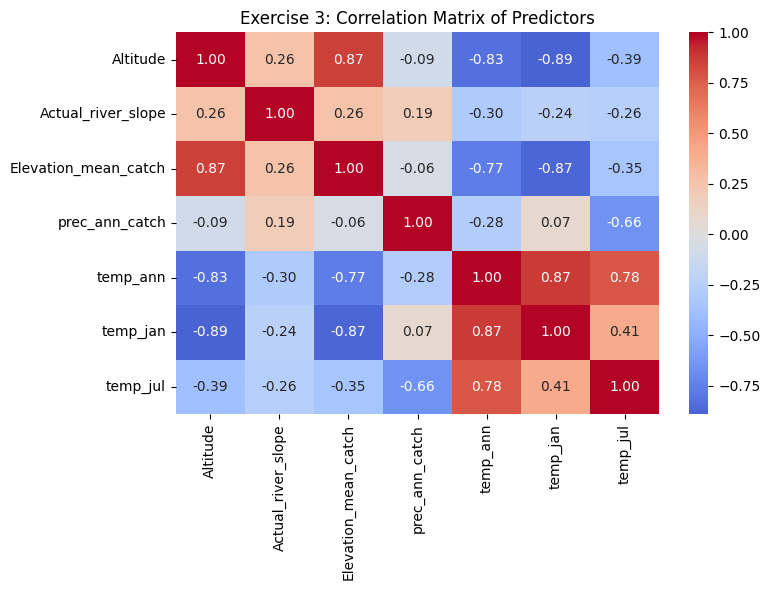

EXERCISE 3: Parsimonious Model
Selected predictors: ['Altitude', 'Actual_river_slope', 'prec_ann_catch', 'temp_ann']
Removed: Elevation_mean_catch (correlated with Altitude), temp_jan and temp_jul (correlated with temp_ann)

                            OLS Regression Results                            
Dep. Variable:               Total_sp   R-squared:                       0.151
Model:                            OLS   Adj. R-squared:                  0.150
Method:                 Least Squares   F-statistic:                     214.1
Date:                Thu, 14 May 2026   Prob (F-statistic):          2.72e-169
Time:                        15:28:44   Log-Likelihood:                -10931.
No. Observations:                4819   AIC:                         2.187e+04
Df Residuals:                    4814   BIC:                         2.190e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                           

In [17]:
# ============================================
# EXERCISE 3: Multicollinearity & Parsimonious Model
# ============================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

print("="*60)
print("EXERCISE 3: Multicollinearity Check")
print("="*60)

# Calculate VIF
X = data[predictors].copy()
Xc = sm.add_constant(X)
vif_data = []
for i in range(Xc.shape[1]):
    vif = variance_inflation_factor(Xc.values, i)
    vif_data.append({'variable': Xc.columns[i], 'VIF': round(vif, 2)})

vif_df = pd.DataFrame(vif_data)
print(vif_df.sort_values('VIF', ascending=False))
print("\n")

# Correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(data[predictors].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Exercise 3: Correlation Matrix of Predictors')
plt.tight_layout()
plt.show()

# Build parsimonious model
selected_predictors = ['Altitude', 'Actual_river_slope', 'prec_ann_catch', 'temp_ann']

print("="*60)
print("EXERCISE 3: Parsimonious Model")
print("="*60)
print(f"Selected predictors: {selected_predictors}")
print("Removed: Elevation_mean_catch (correlated with Altitude), temp_jan and temp_jul (correlated with temp_ann)\n")

reduced_formula = f'{response} ~ ' + ' + '.join(selected_predictors)
reduced_model = smf.ols(reduced_formula, data=data).fit()
print(reduced_model.summary())

# Compare full vs reduced model
print("\n" + "="*60)
print("Model Comparison")
print("="*60)
print(f"Full model (7 predictors) R²: {multi_model.rsquared_adj:.4f}")
print(f"Reduced model (4 predictors) R²: {reduced_model.rsquared_adj:.4f}")
print(f"Difference: {abs(multi_model.rsquared_adj - reduced_model.rsquared_adj):.4f}")

# Check which variables remain significant in reduced model
significant_reduced = [p for p in selected_predictors if reduced_model.pvalues[p] < 0.05]
print(f"\nSignificant variables in reduced model: {significant_reduced}")

# Compare coefficients between full and reduced models
coef_comparison = pd.DataFrame({
    'variable': ['const'] + selected_predictors,
    'full_model_coef': [multi_model.params.get('Intercept', np.nan)] + [multi_model.params.get(p, np.nan) for p in selected_predictors],
    'reduced_model_coef': reduced_model.params.values
})
print("\nCoefficient Comparison (Full vs Reduced Model):")
print(coef_comparison)